# Exam Project - Introduction to Social Data Science
August 28, 2024

## Project: Forecasting Vote Counts for Danish Borgerforslag

## Group 7:
- Oliver Nyrop Weeks (vsn684)
- Sofus Galavits Møller (qvc730)
- Victor V. Kristensen (gcp458)
- Jonas T. Schmidt (mcp656)

## Load modules

In [33]:
# Module Imports
import pandas as pd            # For data manipulation and analysis
from bs4 import BeautifulSoup  # For parsing HTML content
import time                    # For managing time delays during scraping
import tqdm                    # For displaying progress bars during scraping
import pprint                  # For neatly displaying JSON cod
import re                      # For pattern recognition in extracted HTML
import os                      # For interacting with the operating system (e.g., file paths, environment variables)

import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "Output"

## Check dataset

In [34]:
# Load the dataset from the CSV file
loaded_df = pd.read_csv("data/df_after_categorization.csv")

# Display the first few rows of the loaded DataFrame
loaded_df

,Title,Start Date,Votes,Body Text,Num Coauthors,Days from start to scrape,Days from start to end,Lifetime,Month_2,Month_3,...,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10
0,Bedsteforældre har også ret til samvær,2024-02-20,174,Bedsteforældre skal ligestilles i forhold til ...,3,180,180,180,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,Tilbageførsel af Beslutningsansvar vedrørende ...,2024-02-20,45,Dette forslag har til formål at ændre den nuvæ...,3,180,180,180,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Inddrivelsesrenten skal være fradragsberettige...,2024-02-20,165,"Jeg foreslår, at inddrivelsesrenten skal være ...",3,180,180,180,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,"Juridisk abort til mænd, under lign. forudsætn...",2024-02-12,4250,Juridisk abort til mænd Forståelsen af begreb...,4,188,180,180,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Forbud mod seksuelle forhold mellem enkeltpers...,2024-02-09,295,"På trods af en ny lov omhandlende grooming, bl...",3,191,180,180,True,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1685,Grøn mad i alle offentlige køkkener,2018-01-30,12344,"Folketinget anmodes om at vedtage ved lov, at ...",10,2392,180,180,False,False,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1686,Opæhvelse af begrænsning på 45 knallerter,2018-01-30,189,Jeg stiller hermed forslag om at ophævelsen af...,3,2392,180,180,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1687,Automatisk førtidspension til personer der har...,2018-01-30,66,Forslaget er at man automatisk giver førtidspe...,4,2392,180,180,False,False,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1688,POLITISK FORSLAG TIL HØRING I FOLKETINGET OM Æ...,2018-01-30,597,"Lovforslaget går i sin enkelhed ud på, at sikr...",3,2392,180,180,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Key exploratory numbers:

### First proposal

In [35]:
earliest_start_date = loaded_df['Start Date'].min()

# Display the earliest "Start Date"
print(f"The earliest Start Date is: {earliest_start_date}")

The earliest Start Date is: 2018-01-30


In [36]:
latest_start_date = loaded_df['Start Date'].max()

# Display the earliest "Start Date"
print(f"The earliest Start Date is: {latest_start_date}")

The earliest Start Date is: 2024-02-20


### Number of iniative swith over 50,000 votes

In [37]:
# Filter the DataFrame to get only those rows where the vote count is greater than 50,000
votes_over_50000 = loaded_df[loaded_df['Votes'] > 50000]

# Count the number of such rows
num_initiatives_over_50000 = votes_over_50000.shape[0]

print(f"Number of initiatives with votes over 50,000: {num_initiatives_over_50000}")

Number of initiatives with votes over 50,000: 0


## Summary Statistics

Summary statistics for the numeric variables:

In [38]:
import os
import pandas as pd

# Assuming 'loaded_df' is your DataFrame

# Simple descriptions for each variable, with the unit where applicable
variable_descriptions = {
    'Votes': r'Votes \\ \hspace{1cm}(Amount)',
    'Num Coauthors': r'Num. Coauthors \\ \hspace{1cm}(Amount)',
    'Days from start to scrape': r'Days from start to scrape \\ \hspace{1cm}(Days)',
    'Days from start to end': r'Days from start to end \\ \hspace{1cm}(Days)',
    'Lifetime': r'Lifetime \\ \hspace{1cm}(Days)',
    'Start Month': r'Start Month \\ \hspace{1cm}(Month)',
    'Title Length': r'Title Length \\ \hspace{1cm}(Characters)',
    'Body Text Length': r'Body Text Length \\ \hspace{1cm}(Characters)',
    'Title Uppercase Count': r'Title Uppercase Count \\ \hspace{1cm}(Count)',
    'Body Text Uppercase Count': r'Body Text Uppercase Count \\ \hspace{1cm}(Count)',
    'Title Lowercase Count': r'Title Lowercase Count \\ \hspace{1cm}(Count)',
    'Body Text Lowercase Count': r'Body Text Lowercase Count \\ \hspace{1cm}(Count)',
    'Body Text LIX Score': r'Body Text LIX Score \\ \hspace{1cm}(Score)',
    'Distance to parliament km': r'Distance to parliament \\ \hspace{1cm}(km)'
}

# Function to encapsulate each description in the LaTeX tabular format
def format_variable_description(description):
    return r'\begin{tabular}{@{}l@{}} ' + description + r' \end{tabular}'

# Apply the formatting function to each entry in the dictionary
formatted_variable_descriptions = {key: format_variable_description(value) for key, value in variable_descriptions.items()}

# Filter out the 'topic' columns from the DataFrame
non_topic_columns = [col for col in loaded_df.columns if not col.startswith('topic')]
filtered_df = loaded_df[non_topic_columns]

# Get the summary statistics for the filtered DataFrame and transpose the table
summary_statistics = filtered_df.describe().transpose()

# Reorder the DataFrame rows to place Title-related rows first and then Body Text-related rows
order = [
    'Votes', 'Num Coauthors',
    'Days from start to scrape', 'Days from start to end','Lifetime', 'Start Month', 
    'Title Length', 'Title Uppercase Count', 'Title Lowercase Count',
    'Body Text Length', 'Body Text Uppercase Count', 'Body Text Lowercase Count', 'Body Text LIX Score',
    'Distance to parliament km'
]

summary_statistics = summary_statistics.loc[[col for col in order if col in summary_statistics.index]]

# Replace index labels with formatted descriptions
summary_statistics.index = summary_statistics.index.map(lambda x: formatted_variable_descriptions.get(x, x))

# Capitalize the first letter of each statistic name
summary_statistics.columns = summary_statistics.columns.str.capitalize()

# Convert the summary statistics to a LaTeX table with formatting and escape special characters
latex_table = summary_statistics.to_latex(
    index=True,                # Include the row names (e.g., variable names)
    float_format="%.1f",       # Format the floating-point numbers to 1 decimal place
    caption="Summary Statistics for Numeric Variables",  # Add a caption for the table
    label="tab:summary",       # Add a label for referencing in LaTeX
    escape=False               # Do not escape special characters to allow LaTeX formatting
)
print(latex_table)

# Create the output directory if it doesn't exist
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

# Define the output file path
output_file_path = os.path.join(output_dir, "summary_table.tex")

# Write the LaTeX table to a file
with open(output_file_path, "w") as file:
    file.write(latex_table)

# Confirm the file was created
print(f"LaTeX table saved to: {output_file_path}")


\begin{table}
\caption{Summary Statistics for Numeric Variables}
\label{tab:summary}
\begin{tabular}{lrrrrrrrr}
\toprule
 & Count & Mean & Std & Min & 25% & 50% & 75% & Max \\
\midrule
\begin{tabular}{@{}l@{}} Votes \\ \hspace{1cm}(Amount) \end{tabular} & 1690.0 & 1725.6 & 4447.5 & 6.0 & 104.2 & 281.5 & 1049.0 & 47951.0 \\
\begin{tabular}{@{}l@{}} Num. Coauthors \\ \hspace{1cm}(Amount) \end{tabular} & 1690.0 & 3.9 & 1.7 & 3.0 & 3.0 & 3.0 & 4.0 & 10.0 \\
\begin{tabular}{@{}l@{}} Days from start to scrape \\ \hspace{1cm}(Days) \end{tabular} & 1690.0 & 1274.6 & 637.0 & 180.0 & 786.2 & 1244.0 & 1815.0 & 2392.0 \\
\begin{tabular}{@{}l@{}} Days from start to end \\ \hspace{1cm}(Days) \end{tabular} & 1690.0 & 180.1 & 0.3 & 180.0 & 180.0 & 180.0 & 180.0 & 181.0 \\
\begin{tabular}{@{}l@{}} Lifetime \\ \hspace{1cm}(Days) \end{tabular} & 1690.0 & 180.1 & 0.3 & 180.0 & 180.0 & 180.0 & 180.0 & 181.0 \\
\begin{tabular}{@{}l@{}} Title Length \\ \hspace{1cm}(Characters) \end{tabular} & 1690.0 & 58.7 &

## Summary statistics for votes

In [39]:
import os
import pandas as pd

# Extract the summary statistics specifically for the 'Votes' variable
votes_summary = filtered_df['Votes'].describe().to_frame().transpose()

# Replace the index label with the desired name "Votes (Amount)"
votes_summary.index = ["Votes (Amount)"]

# Capitalize the first letter of each statistic name
votes_summary.columns = votes_summary.columns.str.capitalize()

# Convert the summary statistics for 'Votes' to a LaTeX table with formatting and escape special characters
latex_votes_table = votes_summary.to_latex(
    index=True,                # Include the row name (i.e., the variable name)
    float_format="%.1f",       # Format the floating-point numbers to 1 decimal place
    caption="Summary Statistics for Votes",  # Add a caption specifically for the 'Votes' variable
    label="tab:votes_summary", # Add a label for referencing in LaTeX
    escape=False               # Do not escape special characters to allow LaTeX formatting
)

print(latex_votes_table)

# Create the output directory if it doesn't exist
output_dir = "Output"
os.makedirs(output_dir, exist_ok=True)

# Define the output file path specifically for the 'Votes' summary table
output_file_path_votes = os.path.join(output_dir, "votes_summary_table.tex")

# Write the LaTeX table for 'Votes' to a file
with open(output_file_path_votes, "w") as file:
    file.write(latex_votes_table)

# Confirm the file was created
print(f"LaTeX table for 'Votes' saved to: {output_file_path_votes}")


\begin{table}
\caption{Summary Statistics for Votes}
\label{tab:votes_summary}
\begin{tabular}{lrrrrrrrr}
\toprule
 & Count & Mean & Std & Min & 25% & 50% & 75% & Max \\
\midrule
Votes (Amount) & 1690.0 & 1725.6 & 4447.5 & 6.0 & 104.2 & 281.5 & 1049.0 & 47951.0 \\
\bottomrule
\end{tabular}
\end{table}

LaTeX table for 'Votes' saved to: Output/votes_summary_table.tex


## Time investigation

/var/folders/s3/s58q439926xb4bq1gzzpvw0r0000gn/T/ipykernel_51019/3986560626.py:32: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range('2023-01-01', periods=12, freq='M').strftime('%B')


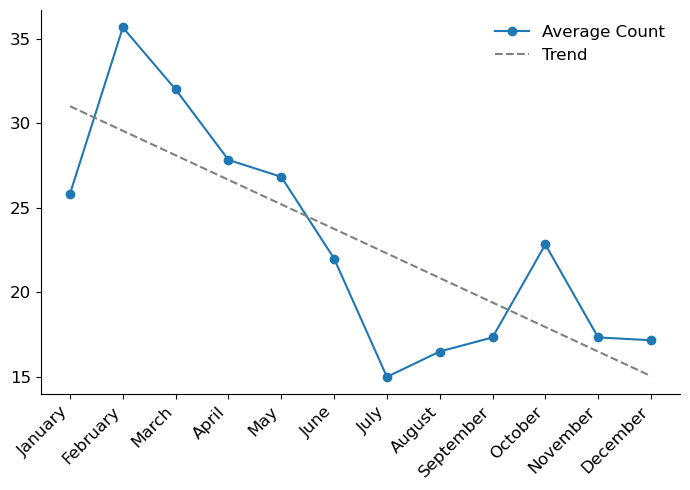

Image saved to: Output/season_plot.pdf


In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assuming loaded_df is already provided

# Copy the original DataFrame to avoid overwriting
loaded_df2 = loaded_df.copy()

# Ensure 'Start Date' is in datetime format
loaded_df2['Start Date'] = pd.to_datetime(loaded_df2['Start Date'], errors='coerce')

# Extract the month (ignoring the year) and year
loaded_df2['Month'] = loaded_df2['Start Date'].dt.month
loaded_df2['Year'] = loaded_df2['Start Date'].dt.year

# Remove all observations from 2024
loaded_df2 = loaded_df2[loaded_df2['Year'] != 2024]

# Count occurrences by month (aggregated across all years)
monthly_counts = loaded_df2['Month'].value_counts().sort_index()

# Calculate the number of years with data for each month
years_per_month = loaded_df2.groupby('Month')['Year'].nunique()

# Calculate the average number of observations per month
monthly_avg_counts = monthly_counts / years_per_month

# Map month numbers to month names
months = pd.date_range('2023-01-01', periods=12, freq='M').strftime('%B')

# Create the plot with specified figure size
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the average count per month
ax.plot(monthly_avg_counts.index, monthly_avg_counts.values, marker='o', label='Average Count')

# Perform linear regression to add a trend line
slope, intercept, r_value, p_value, std_err = linregress(monthly_avg_counts.index, monthly_avg_counts.values)
trendline = slope * monthly_avg_counts.index + intercept
ax.plot(monthly_avg_counts.index, trendline, color='grey', linestyle='--', label='Trend')

# Set the labels and title with increased font size
#ax.set_ylabel('Average Count per Month', fontsize=12)
#ax.set_title('Average Count per Month (Excluding 2024 Data)', fontsize=14)

# Set the x-ticks to display month names with increased font size
ax.set_xticks(monthly_avg_counts.index)
ax.set_xticklabels(months, rotation=45, ha='right', fontsize=12)

# Increase y-tick label size
ax.tick_params(axis='y', labelsize=12)

# Remove the right and left spines (borders)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Add a legend without a box around it and move it slightly down in the right
ax.legend(frameon=False, loc='upper right', fontsize=12)

# Adjust layout to make room for the x-axis labels
plt.tight_layout()

# Define the output directory and file path
output_dir = 'Output'
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist
output_file_path = os.path.join(output_dir, "season_plot.pdf")

# Save the plot to the specified file path with bbox_inches to ensure all elements are included
plt.savefig(output_file_path, bbox_inches='tight')

# Show the plot
plt.show()

# Confirm the file was created
print(f"Image saved to: {output_file_path}")


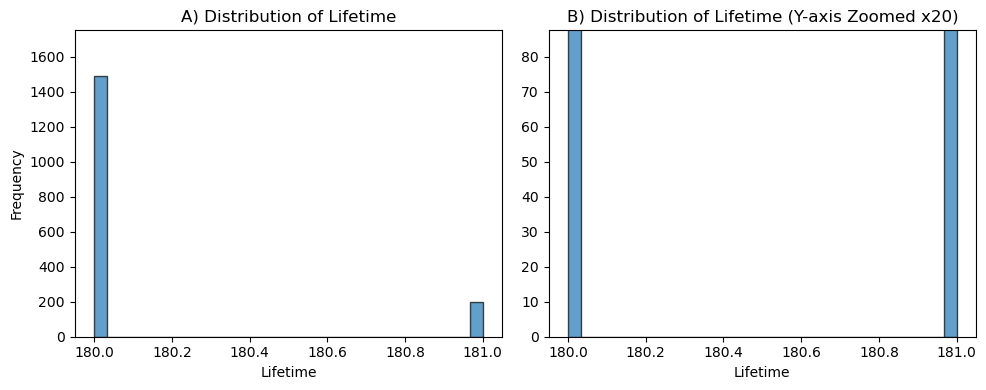

In [41]:
import matplotlib.pyplot as plt
import os

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# Plot the full distribution histogram in the left subplot
ax1.hist(loaded_df['Lifetime'], bins=30, edgecolor='black', alpha=0.7)
ax1.set_title('A) Distribution of Lifetime')
ax1.set_xlabel('Lifetime')
ax1.set_ylabel('Frequency')
ax1.set_ylim(0, 1750)  # Set the y-axis range for the full distribution

# Plot the zoomed-in distribution histogram in the right subplot
ax2.hist(loaded_df['Lifetime'], bins=30, edgecolor='black', alpha=0.7)
ax2.set_title('B) Distribution of Lifetime (Y-axis Zoomed x20)')
ax2.set_xlabel('Lifetime')
ax2.set_ylim(0, 175/2)  # Set the y-axis range for the zoomed-in distribution

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Save the figure as a PDF
output_path = os.path.join(output_dir, "Lifetime_plot.pdf")
fig.savefig(output_path)

# Show the plots
plt.show()


Now find max value of lifetime:

In [42]:
max_lifetime = loaded_df['Lifetime'].max()
max_lifetime

181

## Text analysis

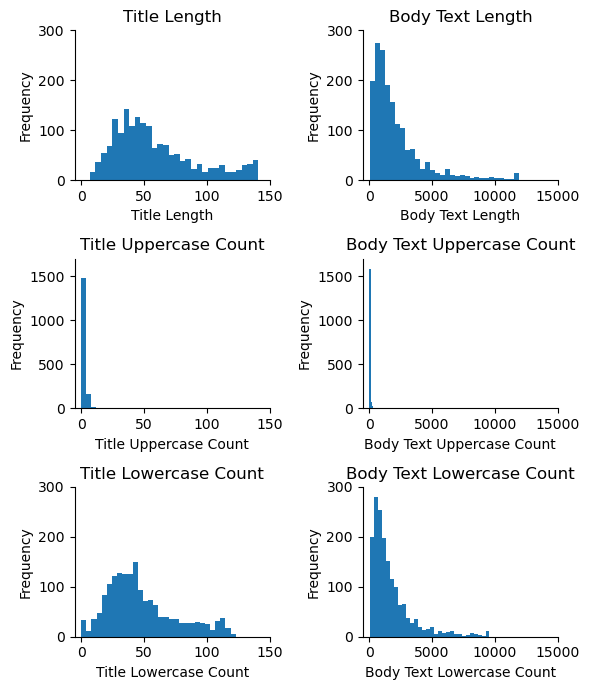

In [43]:
import matplotlib.pyplot as plt

# List of variables to plot in the new order
variables = [
    "Title Length",
    "Body Text Length",
    "Title Uppercase Count",
    "Body Text Uppercase Count",
    "Title Lowercase Count",
    "Body Text Lowercase Count"
]

# Determine the number of subplots (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(6, 7))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot histograms for each variable in a subplot
for i, var in enumerate(variables):
    axes[i].hist(loaded_df[var], bins=30)
    axes[i].set_title(f'{var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    
    # Set y-axis limits based on the row
    if i // 2 == 0:  # First row (0, 1 indices)
        axes[i].set_ylim(0, 300)
    elif i // 2 == 1:  # Second row (2, 3 indices)
        axes[i].set_ylim(0, 1700)
    elif i // 2 == 2:  # Third row (4, 5 indices)
        axes[i].set_ylim(0, 300)
    
    # Set x-axis limits based on the column
    if i % 2 == 0:  # Left column (0, 2, 4 indices)
        axes[i].set_xlim(-5, 150)
    else:  # Right column (1, 3, 5 indices)
        axes[i].set_xlim(-500, 15000)
    
    # Remove the right and top spines
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['top'].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()

# Output
output_path = os.path.join(output_dir, "text_plot.pdf")
fig.savefig(output_path)

# Show
plt.show()


## LIX

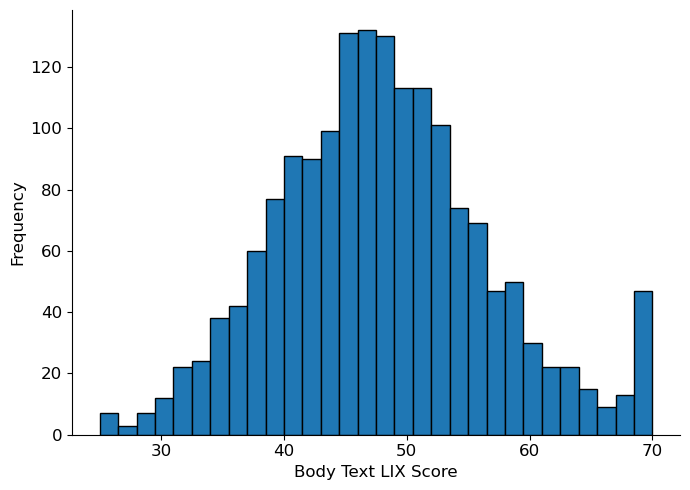

The interval with the most observations is: (46.0, 47.5)


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'loaded_df' is already defined and contains the data
# Creating a new dataset with only the "Body Text LIX Score" column
new_df = loaded_df[['Body Text LIX Score']].copy()

# Plotting the distribution of the "Body Text LIX Score" variable and capturing histogram data
plt.figure(figsize=(7, 5))
counts, bin_edges, _ = plt.hist(new_df['Body Text LIX Score'], bins=30, edgecolor='black')
plt.xlabel('Body Text LIX Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Increase font size for tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove grid lines
plt.grid(False)

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()

# Output
output_path = os.path.join(output_dir, "lix_plot.pdf")
plt.savefig(output_path)

# Show
plt.show()

# Identifying the interval with the most observations
max_count_index = counts.argmax()
most_frequent_interval = (bin_edges[max_count_index], bin_edges[max_count_index + 1])

print(f"The interval with the most observations is: {most_frequent_interval}")


# Sentiments

In [45]:
import pandas as pd

# Assuming 'loaded_df' is already defined and contains the data

# Calculate the counts for each sentiment category
sentiment_counts = pd.DataFrame({
        'Negative': (~(loaded_df['Sentiment_neutral'] | loaded_df['Sentiment_positive'])).sum(),
    'Neutral': loaded_df['Sentiment_neutral'].sum(),
    'Positive': loaded_df['Sentiment_positive'].sum()
}, index=['Count'])

# Convert the DataFrame to a LaTeX table
latex_table = sentiment_counts.to_latex(index=True, caption="Distribution of Sentiment Categories", label="tab:sentiment_distribution")

# Print the LaTeX table
print(latex_table)


\begin{table}
\caption{Distribution of Sentiment Categories}
\label{tab:sentiment_distribution}
\begin{tabular}{lrrr}
\toprule
 & Negative & Neutral & Positive \\
\midrule
Count & 820 & 102 & 768 \\
\bottomrule
\end{tabular}
\end{table}



# Topics

In [46]:
import pandas as pd

# Assuming 'loaded_df' is already defined and contains the data
# Select columns for topics
topic_columns = [f'topic_{i}' for i in range(1, 11)]
topic_distribution = loaded_df[topic_columns].sum()

# Rename the index to be more readable
topic_distribution.index = [f'Topic {i}' for i in range(1, 11)]

# Convert the series to a DataFrame for better formatting
topic_distribution_df = topic_distribution.reset_index()
topic_distribution_df.columns = ['Topic', 'Frequency']

# Ensure frequencies have no decimal numbers (convert to integers)
topic_distribution_df['Frequency'] = topic_distribution_df['Frequency'].astype(int)

# Transpose the DataFrame
transposed_df = topic_distribution_df.set_index('Topic').T

# Generate LaTeX table from the transposed DataFrame
latex_table = transposed_df.to_latex(index=True, caption="Distribution of Topics", label="tab:topic_distribution", float_format="%.0f")

# Print the LaTeX table
print(latex_table)


\begin{table}
\caption{Distribution of Topics}
\label{tab:topic_distribution}
\begin{tabular}{lrrrrrrrrrr}
\toprule
Topic & Topic 1 & Topic 2 & Topic 3 & Topic 4 & Topic 5 & Topic 6 & Topic 7 & Topic 8 & Topic 9 & Topic 10 \\
\midrule
Frequency & 304 & 237 & 251 & 222 & 147 & 119 & 317 & 129 & 108 & 134 \\
\bottomrule
\end{tabular}
\end{table}



## Test plots

Cumulative histogram saved to: Output/cumulative_histogram_votes.png


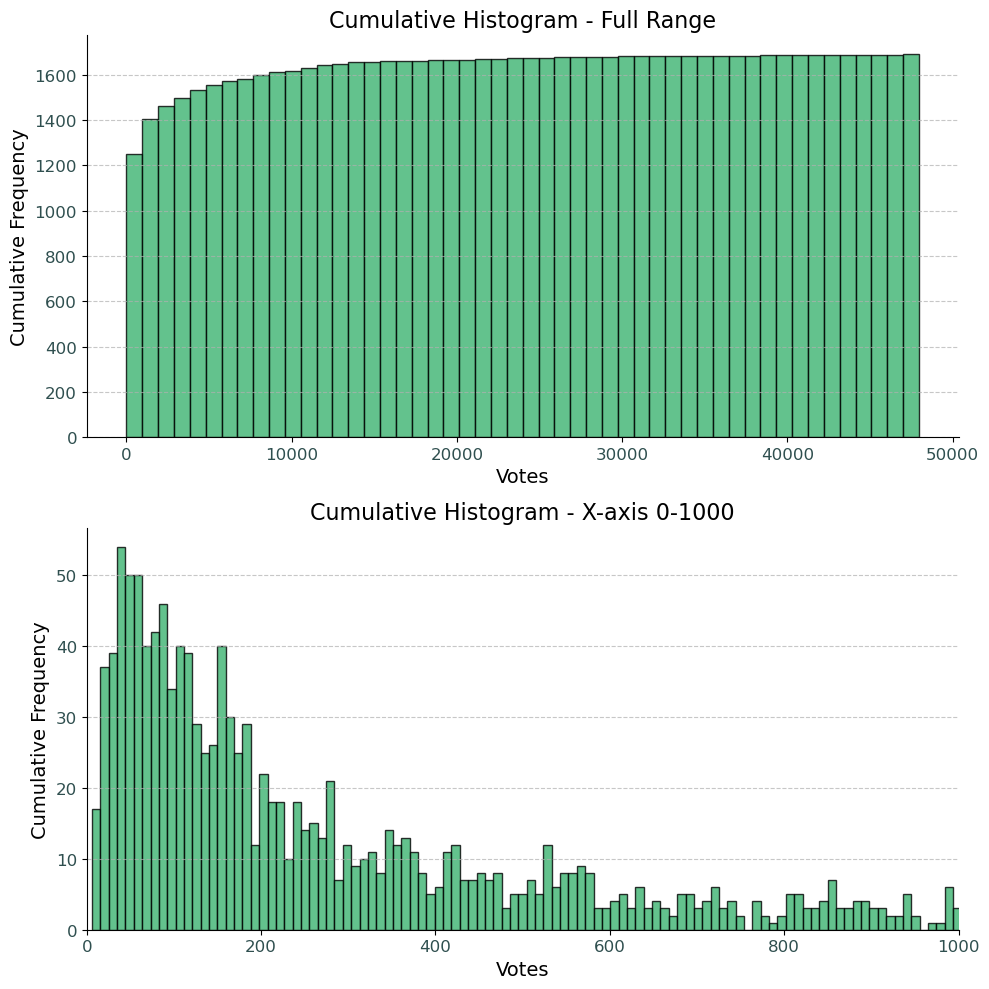

In [47]:
import os
import matplotlib.pyplot as plt

# Assuming 'loaded_df' is your DataFrame containing the 'Votes' column

# Define the output directory and file path
output_file_path = os.path.join(output_dir, "cumulative_histogram_votes.png")

# Create the figure with two subplots
plt.figure(figsize=(10, 10))

# Subplot 1: Full range cumulative histogram
plt.subplot(2, 1, 1)
plt.hist(loaded_df['Votes'], bins=50, cumulative=True, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.xlabel('Votes', fontsize=14)
plt.ylabel('Cumulative Frequency', fontsize=14)
plt.ylim(0, None)
plt.xticks(fontsize=12, color='darkslategray')
plt.yticks(fontsize=12, color='darkslategray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.7)
plt.title('Cumulative Histogram - Full Range', fontsize=16)

# Subplot 2: Cumulative histogram with x-axis limited to 0-1000
plt.subplot(2, 1, 2)
plt.hist(loaded_df['Votes'], bins=5000, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.xlabel('Votes', fontsize=14)
plt.ylabel('Cumulative Frequency', fontsize=14)
plt.ylim(0, None)
plt.xlim(0, 1000)  # Set x-axis limit to 0-1000
plt.xticks(fontsize=12, color='darkslategray')
plt.yticks(fontsize=12, color='darkslategray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.7)
plt.title('Cumulative Histogram - X-axis 0-1000', fontsize=16)

# Tight layout for better spacing
plt.tight_layout()

# Save the plot to the specified file path
plt.savefig(output_file_path)

# Confirm the file was created
print(f"Cumulative histogram saved to: {output_file_path}")


## Lifetime

In [48]:
earliest_start_date = loaded_df['Start Date'].min()

# Display the earliest "Start Date"
print(f"The earliest Start Date is: {earliest_start_date}")

The earliest Start Date is: 2018-01-30


# Creating a pairplot over the features in our model

In [49]:
import pandas as pd

# Load the dataset from the CSV file
features_df = pd.read_csv("Data/df_after_categorization.csv")

# Display the first few rows of the loaded DataFrame
features_df.head(5)

,Title,Start Date,Votes,Body Text,Num Coauthors,Days from start to scrape,Days from start to end,Lifetime,Month_2,Month_3,...,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10
0,Bedsteforældre har også ret til samvær,2024-02-20,174,Bedsteforældre skal ligestilles i forhold til ...,3,180,180,180,True,False,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,Tilbageførsel af Beslutningsansvar vedrørende ...,2024-02-20,45,Dette forslag har til formål at ændre den nuvæ...,3,180,180,180,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,Inddrivelsesrenten skal være fradragsberettige...,2024-02-20,165,"Jeg foreslår, at inddrivelsesrenten skal være ...",3,180,180,180,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,"Juridisk abort til mænd, under lign. forudsætn...",2024-02-12,4250,Juridisk abort til mænd Forståelsen af begreb...,4,188,180,180,True,False,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Forbud mod seksuelle forhold mellem enkeltpers...,2024-02-09,295,"På trods af en ny lov omhandlende grooming, bl...",3,191,180,180,True,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


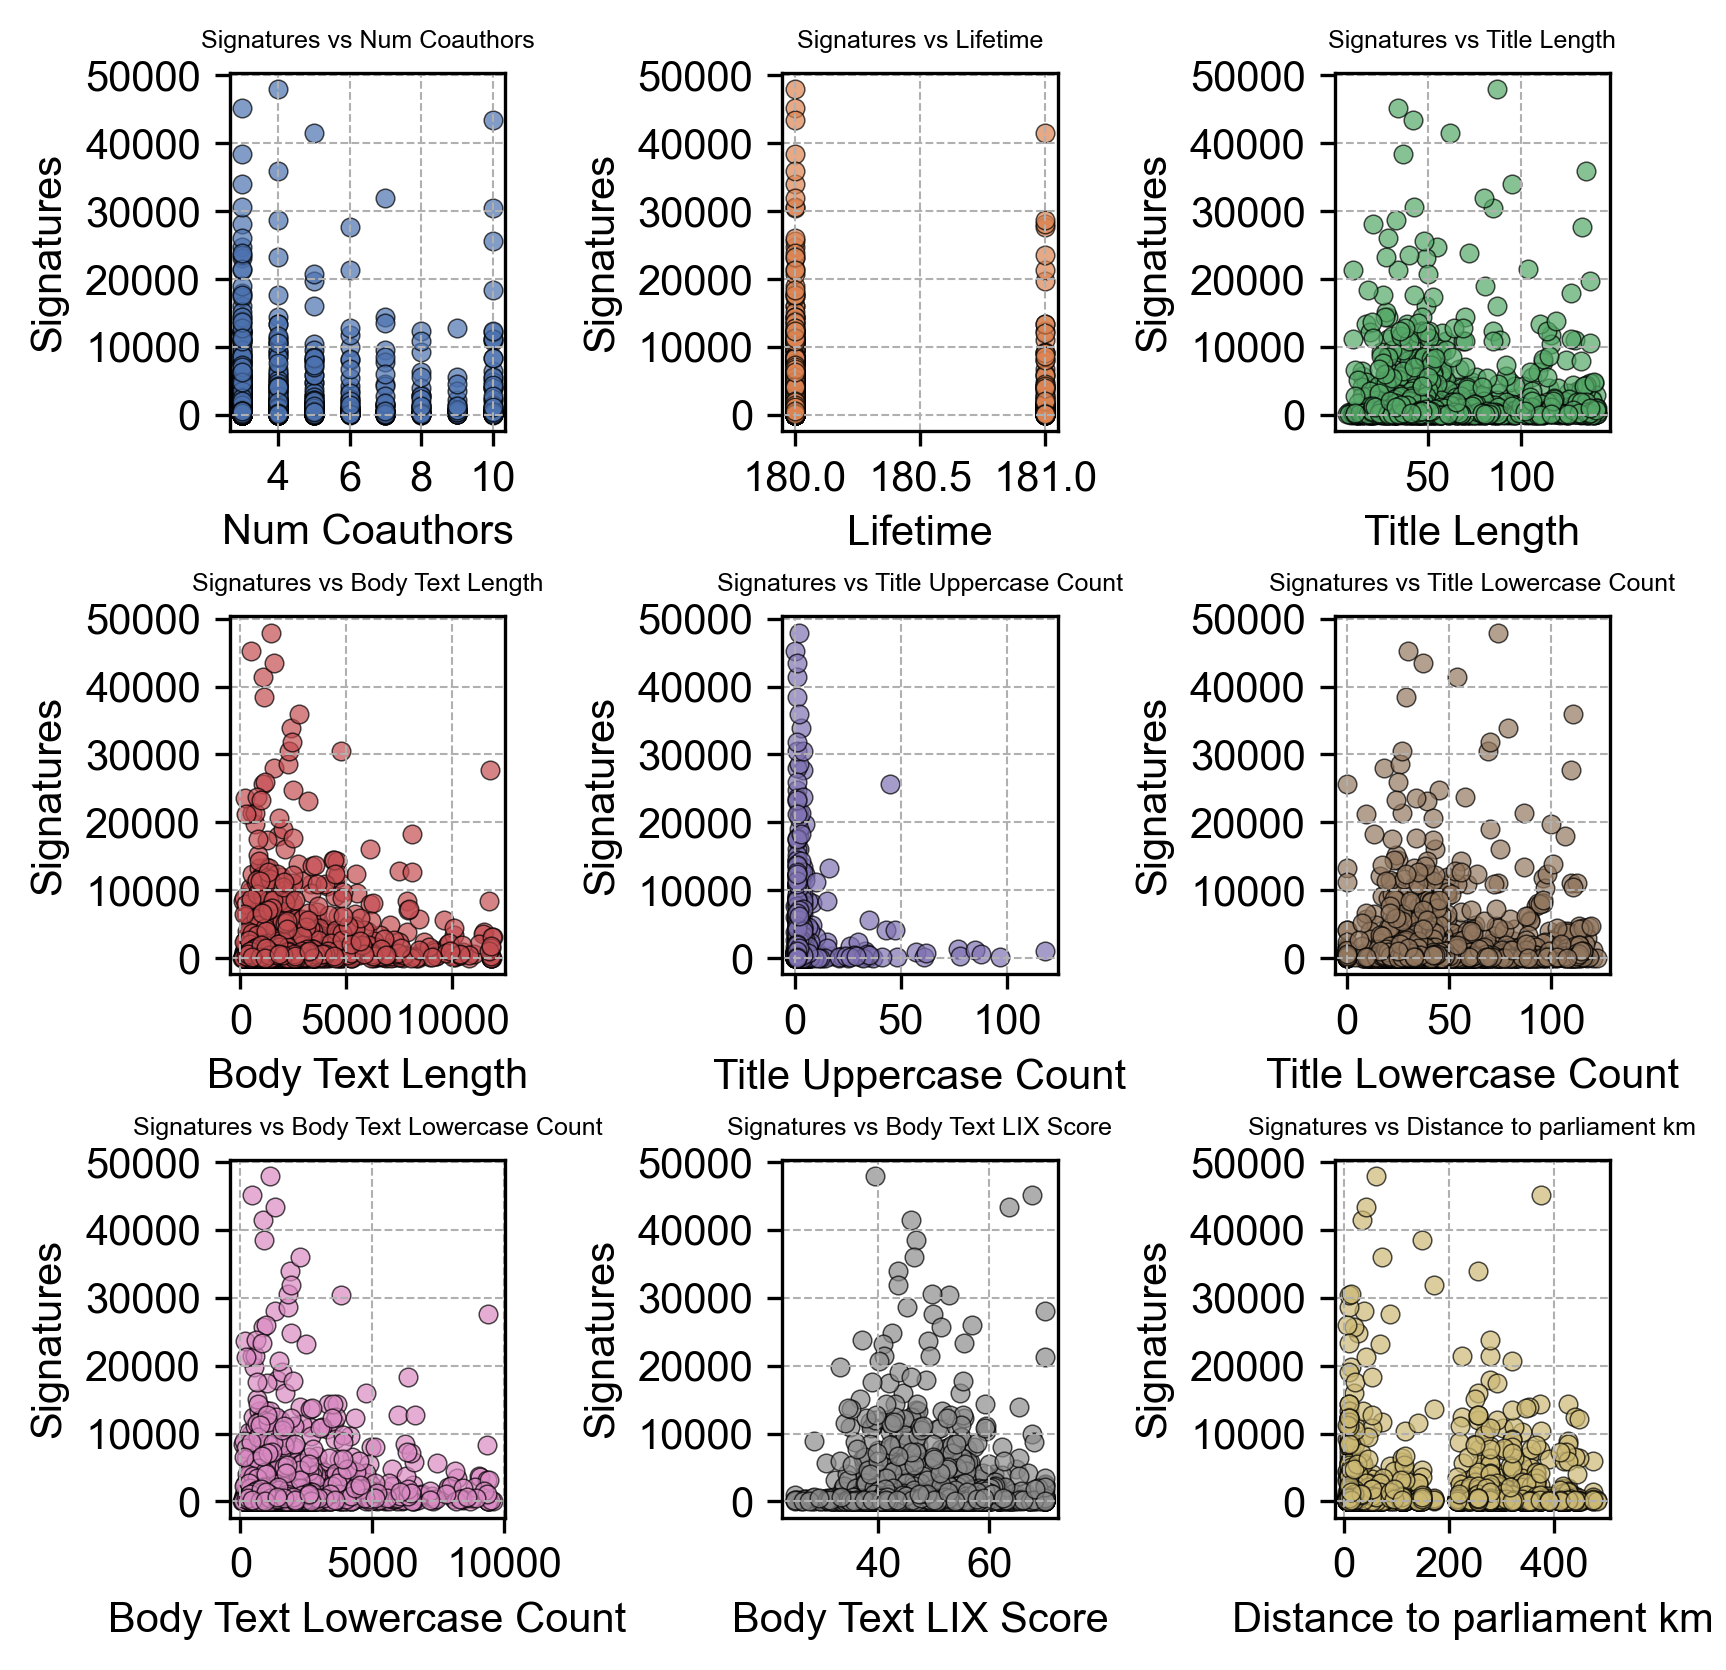

In [50]:
# Creating a plot where the number of signatures are plotted against the features in the dataset
y_variable = 'Votes'
x_variables = ['Num Coauthors', 
               'Lifetime', 
               'Title Length', 
               'Body Text Length', 
               'Title Uppercase Count', 
               'Title Lowercase Count', 
               'Body Text Lowercase Count', 
               'Body Text LIX Score', 
               'Distance to parliament km']

color_palette = sns.color_palette("deep")

fig, axes = plt.subplots(3, 3, figsize=(5.5, 5.5), dpi=300)

axes = axes.flatten()
sns.set(style="whitegrid")
plt.rc('axes', titlesize=6)
plt.rc('axes', labelsize=6)
plt.rc('xtick', labelsize=5)
plt.rc('ytick', labelsize=5)

for i, x_variable in enumerate(x_variables):
    sns.scatterplot(data=features_df, x=x_variable, y=y_variable, ax=axes[i], color=color_palette[i % len(color_palette)], s=20, edgecolor='black', alpha=0.7)
    axes[i].set_xlabel(x_variable)
    axes[i].set_ylabel('Signatures')
    axes[i].set_title(f'Signatures vs {x_variable}', fontsize=6)
    axes[i].grid(True, which='both', linestyle='--', linewidth=0.5)

for i in range(len(x_variables), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(pad=0.4)

plt.savefig('Output/scatterplot_features_overview.pdf', dpi=300, bbox_inches='tight')

plt.show()